## Problem 1: mergesort


Mergesort is a sorting algorithm.  It works as follows.  Given a list of numbers L:

1. Let $L_1$ be the first half of $L$, and the second half of $L$ be the list $L_2$.

2. Recursively mergesort $L_1$ and $L_2$, yielding two sorted lists $S_1$ and $S_2$.

3. Merge $S_1$ and $S_2$ together into a new list $S$ as follows.  Initialize $S$ to be empty. Move either the first element of $S_1$ or the first element of $S_2$, whichever is smaller, to $S$.  Repeat until $S_1$ and $S_2$ are empty.

4. Return the sorted list $S$.


Analyze the running time of mergesort, assuming that the only operation which takes time is comparing two elements.  Note: I don't think you really need generating functions to do this.



## Problem 2: randomly permuting a list

Consider three methods of randomizing a list of length $n$:

*(i)* by tagging each with a random floating point number; sort by this tag.

*(ii)* the Fisher-Yates shuffle: go through the list from start to end, and swap the $j$th element with the $k$th element, where $k$ is a uniformly random number in $j, j+1, \dots, n$). See Wikipedia.

**(a)** Show that *(ii)* is $O(n)$ (if moving is atomic) while *(i)* is $O(N\log N)$.

**(b)** Implement these algorithms and time them. Despite your answer to (a), I imagine that *(i)* is in fact much faster than *(ii)*.  Explain why (or why not).


Here's one way to time code in python - if you find a better way feel free to use that.

In [6]:
from timeit import default_timer as timer

def f(x):
    return sum(t^2 for t in range(x))

for trial in range(1,4):
    print("===============================")
    print("Here we go with trial {}".format(trial))
    start = timer()
    print("the answer is {}".format(f(100000)))
    end = timer()

    elapsed_time = end - start
    print("That took {} seconds".format(elapsed_time))

Here we go with trial 1
the answer is 4999950000
That took 0.012148345995228738 seconds
Here we go with trial 2
the answer is 4999950000
That took 0.008979083970189095 seconds
Here we go with trial 3
the answer is 4999950000
That took 0.009185396018438041 seconds


## Problem 3: Partitions

(a) Write an iterator which iterates over all the partitions of $n$, in reverse lexicographic order.  For instance:  The partitions of 5 are: (5), (4, 1), (3,2), (3,1,1), (2,2,1), (2,1,1,1), (1,1,1,1,1).  Hint: use recursion. 

(b) Verify that the generating function for partitions of $n$ is $$G(x) = \prod_{i \geq 1} \frac{1}{1-x^i}.$$ 

(c) Use your iterator to count the partitions of $n$  $(0 \leq n \leq 10)$ and compare with (b).  I suggest using sympy's FormalPowerSeries to do this.



## Problem 4: Reduced words and wiring diagrams

We start with some definitions.
- If $1 \leq i < n$, the *simple transposition* $\tau_i \in S_n$ is the permutation which swaps $i$ and $i+1$, but fixes all other numbers.
- A *word for the permutation $\pi$* is a list $a = a_1 a_2 \ldots a_k$ such that $\tau_{a_1} \tau_{a_2} \dots \tau_{a_k}=\pi$.  The word $a$ is said to be *reduced* if $k = \text{inv}(\pi)$. To multiply permutations, use function composition: $\pi \sigma = \pi \circ \sigma$.
- See below for an example of a *wiring diagram* for a reduced word.

For example: the permutation $3142 \in S_4$ has two reduced words: 213 and 231, because $\tau_2\tau_1\tau_3 = \tau_2 \tau_3 \tau_1 = 3142$.

**(a)** Write a function which, given a reduced word, finds the permutation associated to it (and verify that 213 and 231 are reduced words for 3142).

**(b)** Write a function which detects whether a word is reduced or not.  Run the code for part (a); then, count the inversions for that permutation and see if it's the same as the length of the word.

**(c)** Write code which uses matplotlib to draw a wiring diagram for a reduced word (see below, where I draw a wiring diagram by hand).  

Here's some sample code which draws the wiring diagram for the reduced word 231: left-to-right, we have a crossing in the second line, then a crossing in the third line, then a crossing in the first line. 
Note that the lines (the "wires") are labeled $1$ through $4$ on the left - and then the same wires appear in order 3,1,4,2 on the right, so you can read off that the permutation is 3142 (but think carefully about why this is).  The colors are optional.

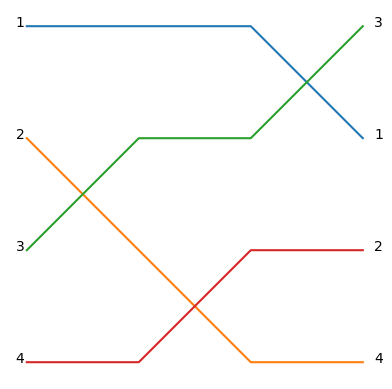

In [30]:
import matplotlib.pyplot as plt

def draw_231(ax):
    ax.text(-0.1,3,"1")
    ax.text(-0.1,2,"2")
    ax.text(-0.1,1,"3")
    ax.text(-0.1,0,"4")
    x = (0,1,2,3)
    ax.plot(x,(3,3,3,2))
    ax.plot(x,(2,1,0,0))
    ax.plot(x,(1,2,2,3))
    ax.plot(x,(0,0,1,1))
    ax.text(3.1,3,"3")
    ax.text(3.1,2,"1")
    ax.text(3.1,1,"2")
    ax.text(3.1,0,"4")
    ax.axis("off")
    ax.set_aspect(1)
    return ax
    
fig, ax = plt.subplots()
draw_231(ax)
plt.show()


## Problem 5: iterators for reduced words

This continues on from Problem 3 - I split it up, as it was getting kinda long.  

The *descent set* of a permutation $\pi$ in one-line notation is the set of indicies $i$ such that $\pi(i+1) > \pi(i)$.

**(a)** Explain why a reduced word for $\pi$ must end with $i$, for some $i$ in the descent set of $\pi$.

**(b)** Write a function which computes the descent set of a permutation.

**(c)** Write an iterator which returns, in turn, the reduced words for $\pi$.  

There should be 16 reduced words for the permutation $4321 \in S_4$, for example, and 768 reduced words for the permutation $54321 \in S_5$.